# Day 32: Student Performance & Learning Analytics

**Dataset:** `Student_Learning_Analytics_Cleaned.csv`

This notebook is the second of three days in the Student Performance & Learning Analytics
project. It continues from the cleaned dataset saved on Day 31 and covers subject-wise
performance analysis, correlation analysis, student performance visualizations, and feature
engineering.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the cleaned dataset saved on Day 31
df = pd.read_csv("../datasets/Student_Learning_Analytics_Cleaned.csv")

SCORE_COLS = ["math_score", "reading_score", "writing_score", "science_score"]

# Preview the data
df.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade,average_score,attendance_percentage,study_hours_per_week
0,std-01,male,group D,some college,1,1,89,38,85,26,238,C,59.50,80.5,3.3
1,std-02,male,group B,high school,1,0,65,100,67,96,328,A,82.00,75.9,6.2
2,std-03,male,group C,master's degree,1,0,10,99,97,58,264,B,66.00,86.7,7.7
3,std-04,male,group D,some college,1,1,22,51,41,84,198,D,49.50,82.9,5.4
4,std-05,male,group C,some college,0,1,26,58,64,65,213,C,53.25,58.2,11.3


In [2]:
print(df.shape)
print("Missing values:", df.isna().sum().sum())
df.info()

(9991, 15)
Missing values: 0
<class 'pandas.DataFrame'>
RangeIndex: 9991 entries, 0 to 9990
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9991 non-null   str    
 1   gender                       9991 non-null   str    
 2   race_ethnicity               9991 non-null   str    
 3   parental_level_of_education  9991 non-null   str    
 4   lunch                        9991 non-null   int64  
 5   test_preparation_course      9991 non-null   int64  
 6   math_score                   9991 non-null   int64  
 7   reading_score                9991 non-null   int64  
 8   writing_score                9991 non-null   int64  
 9   science_score                9991 non-null   int64  
 10  total_score                  9991 non-null   int64  
 11  grade                        9991 non-null   str    
 12  average_score                9991 non-null   float64
 13  

**A note on the data:** `attendance_percentage` and `study_hours_per_week` are the simulated
columns added on Day 31, built with a link to performance. Relationships involving those two
columns are therefore partly by construction, and the analysis here is meant to practice the
workflow.

## 2. Subject-Wise Performance Analysis

**Summary statistics for each subject, sorted from highest to lowest average**

In [3]:
subject_summary = df[SCORE_COLS].agg(["mean", "median", "std", "min", "max"]).T.round(1)
subject_summary.sort_values("mean", ascending=False)

,mean,median,std,min,max
writing_score,71.4,72.0,18.2,10.0,100.0
reading_score,70.1,71.0,19.0,17.0,100.0
science_score,66.1,67.0,19.3,9.0,100.0
math_score,57.2,58.0,21.7,0.0,100.0


**Pass rate for each subject**

The dataset has no official passing mark, so a simple **50-point mark** is used here as an
assumption.

In [4]:
PASS_MARK = 50

pass_rates = ((df[SCORE_COLS] >= PASS_MARK).mean() * 100).round(1)
print("Pass rate per subject (%):")
print(pass_rates)

passed_all = (df[SCORE_COLS] >= PASS_MARK).all(axis=1)
print(f"\nStudents who passed all four subjects: {passed_all.sum()} ({passed_all.mean() * 100:.1f}%)")

Pass rate per subject (%):
math_score       63.8
reading_score    85.1
writing_score    87.7
science_score    79.5
dtype: float64

Students who passed all four subjects: 3983 (39.9%)


**Each student's strongest and weakest subject**

If two subjects tie for a student, `idxmax()` and `idxmin()` pick the first one in column
order.

In [5]:
best_subject = df[SCORE_COLS].idxmax(axis=1).str.replace("_score", "")
weakest_subject = df[SCORE_COLS].idxmin(axis=1).str.replace("_score", "")

strength_table = pd.DataFrame({
    "best_subject_count": best_subject.value_counts(),
    "weakest_subject_count": weakest_subject.value_counts(),
})
strength_table

,best_subject_count,weakest_subject_count
math,1381,4522
reading,3281,1869
science,2089,2214
writing,3240,1386


**Observation:** math is the weakest subject on every measure: it has the lowest average
(57.2), the widest spread (standard deviation 21.7), and the lowest pass rate at 63.8%,
compared to 87.7% for writing, 85.1% for reading, and 79.5% for science. Only 39.9% of
students reached the 50-point mark in all four subjects at once. Math was also the weakest
subject for far more students than any other (4,522 students), while reading (3,281) and
writing (3,240) were the most common best subjects.

**Average subject scores by gender**

In [6]:
df.groupby("gender")[SCORE_COLS].mean().round(1)

,math_score,reading_score,writing_score,science_score
gender,,,,
female,63.3,68.8,76.2,68.5
male,51.0,71.4,66.6,63.6


**Average subject scores by grade**

In [7]:
df.groupby("grade")[SCORE_COLS].mean().round(1).reindex(["A", "B", "C", "D", "Fail"])

,math_score,reading_score,writing_score,science_score
grade,,,,
A,78.0,86.2,87.1,83.6
B,62.4,73.4,75.5,70.6
C,46.1,62.7,63.1,57.0
D,32.7,54.1,51.5,44.4
Fail,22.5,40.5,42.8,31.0


**Observation:** the gender gap is not the same in every subject. Female students lead by
12.3 points in math and 9.6 in writing, while male students are ahead in reading by 2.6
points. Across grades, math falls the furthest, from an average of 78.0 for grade A students
down to 22.5 for Fail, a drop of 55.5 points compared to 45.7 for reading, so math is the
subject that separates the high and low performers the most.

## 3. Correlation Analysis

**The correlation matrix for scores, attendance, study time, and the two 0/1 background columns**

In [8]:
corr_cols = SCORE_COLS + [
    "average_score", "attendance_percentage", "study_hours_per_week", "test_preparation_course", "lunch",
]
corr_matrix = df[corr_cols].corr()
corr_matrix.round(2)

,math_score,reading_score,writing_score,science_score,average_score,attendance_percentage,study_hours_per_week,test_preparation_course,lunch
math_score,1.00,-0.04,0.10,0.08,0.58,0.22,0.22,0.04,0.04
reading_score,-0.04,1.00,0.02,0.06,0.47,0.16,0.17,0.01,-0.00
writing_score,0.10,0.02,1.00,0.10,0.54,0.19,0.19,0.03,0.02
science_score,0.08,0.06,0.10,1.00,0.57,0.21,0.18,0.00,0.06
average_score,0.58,0.47,0.54,0.57,1.00,0.37,0.36,0.04,0.06
attendance_percentage,0.22,0.16,0.19,0.21,0.37,1.00,0.14,0.01,0.03
study_hours_per_week,0.22,0.17,0.19,0.18,0.36,0.14,1.00,0.42,0.04
test_preparation_course,0.04,0.01,0.03,0.00,0.04,0.01,0.42,1.00,0.04
lunch,0.04,-0.00,0.02,0.06,0.06,0.03,0.04,0.04,1.00


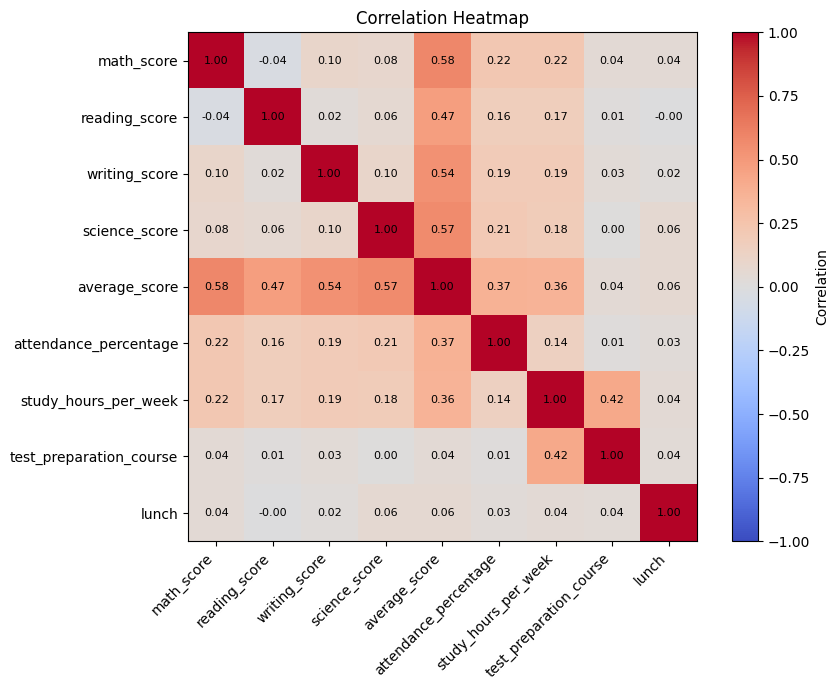

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Everything's correlation with `average_score`, strongest first**

In [10]:
avg_corr = corr_matrix["average_score"].drop("average_score").sort_values(ascending=False).round(2)
avg_corr

math_score                 0.58
science_score              0.57
writing_score              0.54
reading_score              0.47
attendance_percentage      0.37
study_hours_per_week       0.36
lunch                      0.06
test_preparation_course    0.04
Name: average_score, dtype: float64

**How significant are the correlations? Pearson's r with a p-value**

In [11]:
for col in ["attendance_percentage", "study_hours_per_week", "test_preparation_course", "lunch"]:
    r, p = stats.pearsonr(df[col], df["average_score"])
    print(f"{col}: r = {r:.3f}, p-value = {p:.2e}")

attendance_percentage: r = 0.366, p-value = 3.18e-314
study_hours_per_week: r = 0.358, p-value = 2.66e-299
test_preparation_course: r = 0.041, p-value = 4.46e-05
lunch: r = 0.057, p-value = 1.51e-08


**Observation:** the four subject scores are almost uncorrelated with each other (between
-0.04 and 0.10). In real student data, a student who is strong in one subject is usually
somewhat stronger in the others, so this suggests the scores in this dataset were generated
independently. Each subject correlates with `average_score` (0.47 to 0.58) simply because it
is one of the four ingredients of that average, which is expected and not an insight.
Attendance (0.37) and study hours (0.36) are the strongest outside relationships, but both
were simulated with a link to performance, so that is by construction.
`test_preparation_course` (0.04) and `lunch` (0.06) are close to zero. One more thing worth
noting is that the p-values are tiny even for these weak correlations (the
`test_preparation_course` p-value is 4.5e-05), because with about 10,000 students almost any
non-zero correlation is "statistically significant". The **size** of r matters more than the
p-value here. Finally, `test_preparation_course` correlates 0.42 with
`study_hours_per_week`, which also comes from the simulation, where students who took the
course were given extra study hours.

## 4. Student Performance Visualizations

**Spread of each subject score**

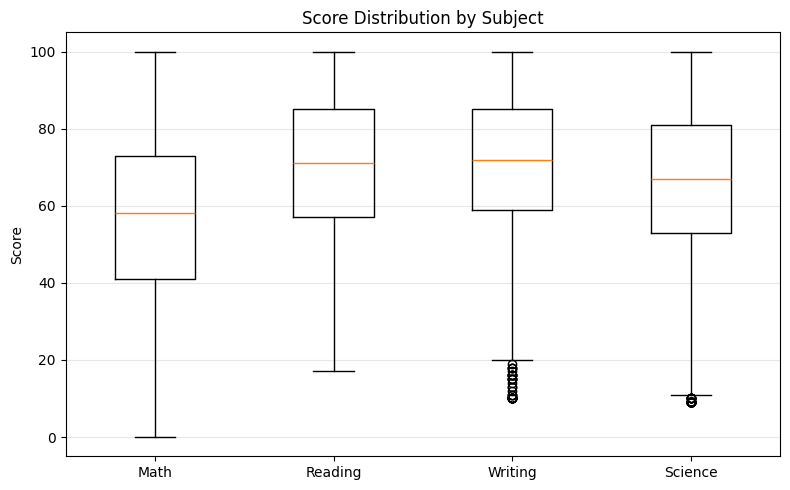

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot([df[col] for col in SCORE_COLS])
plt.xticks(range(1, len(SCORE_COLS) + 1), [col.replace("_score", "").title() for col in SCORE_COLS])
plt.ylabel("Score")
plt.title("Score Distribution by Subject")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Average subject scores by gender**

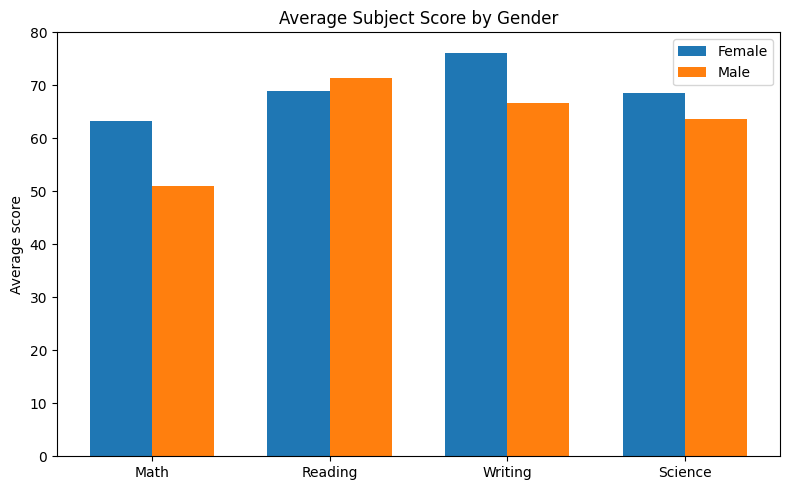

In [13]:
gender_scores = df.groupby("gender")[SCORE_COLS].mean()

x = np.arange(len(SCORE_COLS))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, gender_scores.loc["female"], width, label="Female")
plt.bar(x + width / 2, gender_scores.loc["male"], width, label="Male")
plt.xticks(x, [col.replace("_score", "").title() for col in SCORE_COLS])
plt.ylabel("Average score")
plt.title("Average Subject Score by Gender")
plt.legend()
plt.tight_layout()
plt.show()

**Average subject scores across attendance bands**

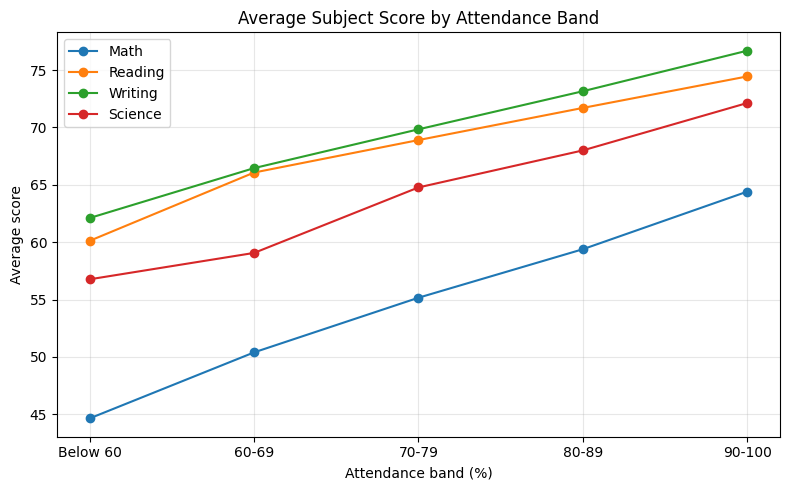

In [14]:
attendance_band = pd.cut(
    df["attendance_percentage"],
    bins=[0, 60, 70, 80, 90, 100.01],
    labels=["Below 60", "60-69", "70-79", "80-89", "90-100"],
    right=False,
)
band_scores = df.groupby(attendance_band, observed=True)[SCORE_COLS].mean()

plt.figure(figsize=(8, 5))
for col in SCORE_COLS:
    plt.plot(band_scores.index.astype(str), band_scores[col], marker="o", label=col.replace("_score", "").title())
plt.xlabel("Attendance band (%)")
plt.ylabel("Average score")
plt.title("Average Subject Score by Attendance Band")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Study hours versus average score, with a straight-line trend**

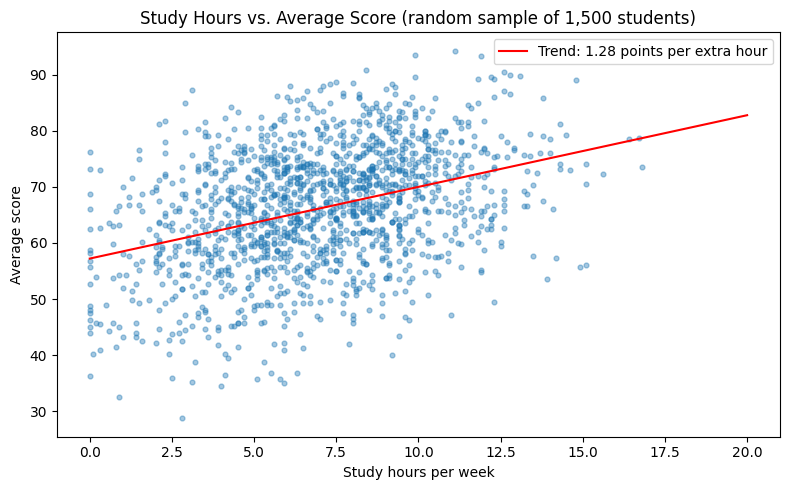

In [15]:
sample = df.sample(1500, random_state=42)
slope, intercept = np.polyfit(df["study_hours_per_week"], df["average_score"], 1)
x_line = np.linspace(0, 20, 100)

plt.figure(figsize=(8, 5))
plt.scatter(sample["study_hours_per_week"], sample["average_score"], alpha=0.4, s=12)
plt.plot(x_line, slope * x_line + intercept, color="red", label=f"Trend: {slope:.2f} points per extra hour")
plt.xlabel("Study hours per week")
plt.ylabel("Average score")
plt.title("Study Hours vs. Average Score (random sample of 1,500 students)")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** the box plot shows math has the lowest median and the widest box, with
reading and writing sitting higher and tighter. The grouped bars make the gender pattern
easy to see: female students are clearly ahead in math and writing, and male students are
slightly ahead in reading. All four subject lines rise with attendance, from the lowest band
to the highest, and they rise together, which fits the fact that attendance was simulated to
track overall performance. The trend line puts each extra weekly study hour at about 1.3
points of average score, but with this much spread around the line, study hours alone are
far from a precise predictor.

## 5. Feature Engineering

New columns are created for Day 33, where a prediction model will be built. They fall into
four groups, and it matters which is which:

- **Analysis features** built from the scores (`best_subject`, `weakest_subject`, `score_range`, `passed_all_subjects`)
- **Encoded predictors** that turn categories into numbers a model can use (`gender_female`, `parent_education_rank`, and the `race_group` dummy columns)
- **Engagement predictors** built from attendance and study time (`attendance_level`, `engagement_score`)
- **A target** for classification (`high_performer`)

**Analysis features from the subject scores**

In [16]:
df_features = df.copy()

df_features["best_subject"] = best_subject
df_features["weakest_subject"] = weakest_subject
df_features["score_range"] = df_features[SCORE_COLS].max(axis=1) - df_features[SCORE_COLS].min(axis=1)
df_features["passed_all_subjects"] = (df_features[SCORE_COLS] >= PASS_MARK).all(axis=1).astype(int)

df_features[["roll_no", "best_subject", "weakest_subject", "score_range", "passed_all_subjects"]].head()

,roll_no,best_subject,weakest_subject,score_range,passed_all_subjects
0,std-01,math,science,63,0
1,std-02,reading,math,35,1
2,std-03,reading,math,89,0
3,std-04,science,math,62,0
4,std-05,science,math,39,0


**Encoded predictors**

`gender` becomes a 0/1 flag. `parental_level_of_education` has a natural order, so it
becomes a rank from 1 to 6 instead of six separate columns. `race_ethnicity` has no order,
so it is one-hot encoded, dropping `group A` as the baseline.

In [17]:
df_features["gender_female"] = (df_features["gender"] == "female").astype(int)

education_order = {
    "some high school": 1,
    "high school": 2,
    "some college": 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6,
}
df_features["parent_education_rank"] = df_features["parental_level_of_education"].map(education_order)

race_dummies = pd.get_dummies(df_features["race_ethnicity"], prefix="race", dtype=int)
race_dummies.columns = [col.replace(" ", "_") for col in race_dummies.columns]
race_dummies = race_dummies.drop(columns="race_group_A")
df_features = pd.concat([df_features, race_dummies], axis=1)

df_features[["gender_female", "parent_education_rank"] + list(race_dummies.columns)].head()

,gender_female,parent_education_rank,race_group_B,race_group_C,race_group_D,race_group_E
0,0,3,0,0,1,0
1,0,2,1,0,0,0
2,0,6,0,1,0,0
3,0,3,0,0,1,0
4,0,3,0,1,0,0


**Engagement predictors from attendance and study time**

`attendance_level` groups attendance into Low (below 75%), Medium (75-89%), and High (90% or
more). `engagement_score` puts attendance and study hours on the same scale (z-scores) and
averages them into a single number, so one column describes how engaged a student is.

In [18]:
df_features["attendance_level"] = pd.cut(
    df_features["attendance_percentage"],
    bins=[0, 75, 90, 100.01],
    labels=["Low", "Medium", "High"],
    right=False,
).astype(str)

def z_score(series):
    return (series - series.mean()) / series.std()

df_features["engagement_score"] = (
    (z_score(df_features["attendance_percentage"]) + z_score(df_features["study_hours_per_week"])) / 2
).round(3)

df_features.groupby("attendance_level")["average_score"].agg(["count", "mean"]).round(1).reindex(["Low", "Medium", "High"])

,count,mean
attendance_level,,
Low,2987,61.6
Medium,5519,67.1
High,1485,71.9


**The classification target: `high_performer`**

A student is a high performer if their average score is **70 or higher**. This is a simple
cutoff chosen so that the two classes are reasonably balanced.

In [19]:
df_features["high_performer"] = (df_features["average_score"] >= 70).astype(int)

print(df_features["high_performer"].value_counts())
print()
print(df_features.groupby("attendance_level")["high_performer"].mean().mul(100).round(1).reindex(["Low", "Medium", "High"]))

high_performer
0    6099
1    3892
Name: count, dtype: int64

attendance_level
Low       23.0
Medium    41.7
High      60.6
Name: high_performer, dtype: float64


**How do the engineered predictors relate to `average_score`?**

In [20]:
engineered_predictors = [
    "gender_female", "parent_education_rank", "race_group_B", "race_group_C", "race_group_D", "race_group_E",
    "engagement_score",
]
df_features[engineered_predictors + ["average_score"]].corr()["average_score"].drop("average_score").sort_values(ascending=False).round(3)

engagement_score         0.478
gender_female            0.287
race_group_C             0.020
race_group_B             0.009
race_group_D            -0.016
race_group_E            -0.018
parent_education_rank   -0.037
Name: average_score, dtype: float64

**Which columns are safe to use as predictors on Day 33?**

In [21]:
feature_roles = pd.DataFrame([
    ("math_score, reading_score, writing_score, science_score", "Source scores", "Do not use as predictors"),
    ("total_score, average_score, grade", "Outcome columns", "Do not use as predictors"),
    ("best_subject, weakest_subject, score_range, passed_all_subjects", "Analysis features", "Built from the scores, so do not use as predictors"),
    ("high_performer", "Classification target", "Built from average_score"),
    ("attendance_percentage, study_hours_per_week, engagement_score, attendance_level", "Engagement predictors", "Safe to use"),
    ("gender_female, parent_education_rank, race_group_B to race_group_E", "Encoded predictors", "Safe to use"),
    ("test_preparation_course, lunch", "Original 0/1 predictors", "Safe to use"),
], columns=["columns", "role", "note"])

feature_roles

,columns,role,note
0,"math_score, reading_score, writing_score, scie...",Source scores,Do not use as predictors
1,"total_score, average_score, grade",Outcome columns,Do not use as predictors
2,"best_subject, weakest_subject, score_range, pa...",Analysis features,"Built from the scores, so do not use as predic..."
3,high_performer,Classification target,Built from average_score
4,"attendance_percentage, study_hours_per_week, e...",Engagement predictors,Safe to use
5,"gender_female, parent_education_rank, race_gro...",Encoded predictors,Safe to use
6,"test_preparation_course, lunch",Original 0/1 predictors,Safe to use


**Observation:** 13 new columns were added, taking the dataset from 15 to 28 columns.
`engagement_score` is the strongest engineered predictor of `average_score` (correlation
0.48), stronger than either attendance or study hours alone, and `gender_female` comes next
(0.29), while the parental education rank and the race group columns are all close to zero.
The `high_performer` target is reasonably balanced (39.0% of students are high performers),
and the share of high performers rises sharply with attendance level, from 23.0% in the Low
group to 60.6% in the High group. The most important point is the table above: every column
built from the scores (the source scores, `total_score`, `average_score`, `grade`, the
analysis features, and `high_performer` itself) **must stay out of the predictors**,
otherwise a model would just be reading the answer from its inputs, which is called data
leakage.

## 6. Save the Dataset with Features

The dataset with the new features is saved so that Day 33 can start straight from the
modeling step.

In [22]:
output_path = "../datasets/Student_Learning_Analytics_Features.csv"
df_features.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", df_features.shape)

Saved: ../datasets/Student_Learning_Analytics_Features.csv
Shape: (9991, 28)


## Outcome

This notebook continued the Student Performance & Learning Analytics project from the
cleaned dataset saved on Day 31. The subject-wise analysis showed that math is the weakest
subject on every measure (average 57.2, pass rate 63.8%, and the biggest drop between grade
A and Fail students), that female students lead in math and writing while male students lead
slightly in reading, and that only 39.9% of students passed all four subjects at a 50-point
mark. The correlation analysis found that the four subject scores are almost uncorrelated
with each other, that attendance (0.37) and study hours (0.36) have the strongest links to
average score, and that `test_preparation_course` and `lunch` have almost none. It also
showed that with about 10,000 students even very weak correlations have tiny p-values, so
the size of r matters more than significance. Because attendance and study hours were
simulated on Day 31, those two relationships are by construction and demonstrate the
workflow rather than a real finding. Five visualizations (a correlation heatmap, a box plot,
a grouped bar chart, an attendance-band line chart, and a scatter plot with a trend line)
made these patterns easy to see. Finally, 13 new features were engineered, including an
`engagement_score`, encoded predictors, and a `high_performer` target, and the dataset was
saved as `Student_Learning_Analytics_Features.csv` with a clear list of which columns must
stay out of the model on Day 33 to avoid data leakage.